# Tech Challenge - Fase 4

## Modelagem de Machine Learning para Predição dos Níveis de Obesidade

### Objetivo

Nesta etapa será realizada a preparação dos dados, o treinamento e a avaliação de diferentes modelos de Machine Learning para prever o nível de obesidade dos indivíduos.

Com base na análise exploratória realizada anteriormente, serão aplicadas técnicas de pré-processamento, treinamento e comparação de algoritmos de classificação, buscando selecionar o modelo com melhor desempenho para utilização na aplicação final.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
        classification_report,
            confusion_matrix
            )

from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

In [7]:
#df = pd.read_csv("Obesity.csv")

# caminho para o csv na maquina local, trocar para git 
df = pd.read_csv('C:/Users/PC/Desktop/Projetos/POS/Obesity.csv', delimiter=',')

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# Removendo registros duplicados
df = df.drop_duplicates()

# Criando a variável BMI
df['BMI'] = df['Weight'] / (df['Height'] ** 2)


df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [9]:
X = df.drop('Obesity', axis=1)
y = df['Obesity']

print(X.shape)
print(y.shape)

(2087, 17)
(2087,)


In [10]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,24.386526,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,24.238227,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,23.765432,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,26.851852,True,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,28.342381,True,...,False,False,False,False,True,False,False,False,True,False


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.2,
                random_state=42,
                    stratify=y
                    )

print(X_train.shape)
print(X_test.shape)

(1669, 24)
(418, 24)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    random_state=42
    )

modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
y_pred = modelo.predict(X_test)

In [15]:
from sklearn.metrics import (
      accuracy_score,
          classification_report,
              confusion_matrix
              )

print("Acurácia:", accuracy_score(y_test, y_pred))

print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.9880382775119617

Relatório de Classificação:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.98      1.00      0.99        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.96      0.97        55
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.99       418
          macro avg       0.99      0.99      0.99       418
       weighted avg       0.99      0.99      0.99       418



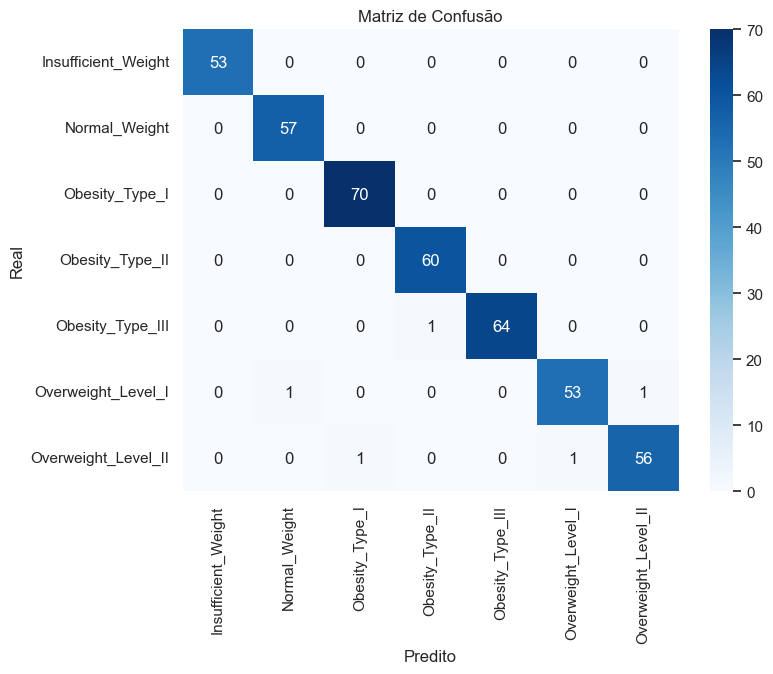

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

In [17]:
import pandas as pd

importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo.feature_importances_
})

importancias = importancias.sort_values(
    by='Importância',
    ascending=False
)

importancias.head(15)

,Variável,Importância
8,BMI,0.351577
2,Weight,0.193395
3,FCVC,0.061236
0,Age,0.059035
1,Height,0.054735
9,Gender_Male,0.046728
4,NCP,0.032326
5,CH2O,0.029171
6,FAF,0.028121
7,TUE,0.025764


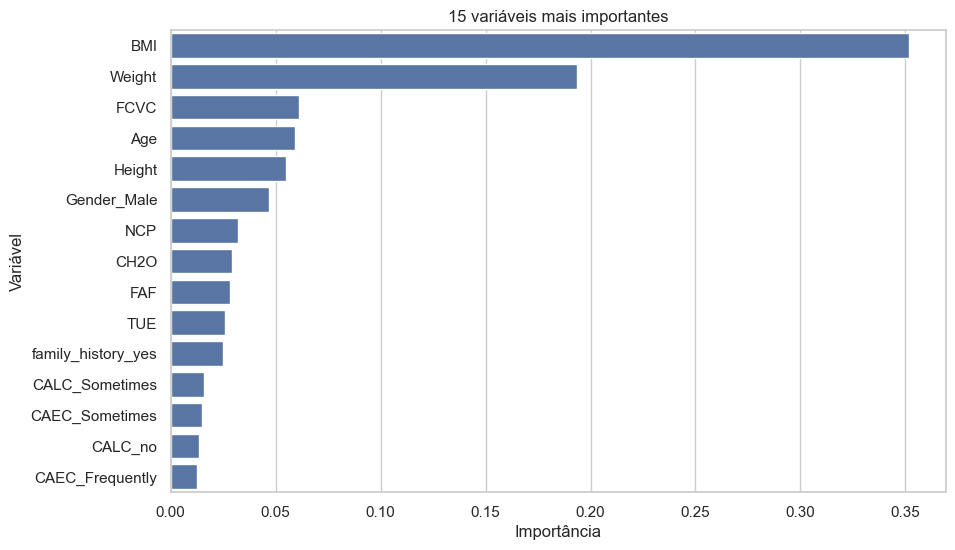

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(15),
    x='Importância',
    y='Variável'
)

plt.title('15 variáveis mais importantes')

plt.show()

## Conclusão - Modelo Random Forest

O modelo Random Forest apresentou excelente desempenho na classificação dos níveis de obesidade, alcançando uma acurácia de **98,80%** no conjunto de teste.

As métricas de Precision, Recall e F1-Score ficaram próximas de **0,99**, demonstrando alta capacidade de generalização e equilíbrio entre as classes.

A matriz de confusão evidencia que praticamente todas as amostras foram classificadas corretamente, ocorrendo apenas poucos erros entre classes de sobrepeso e obesidade com características semelhantes.

A análise da importância das variáveis mostrou que o **IMC (BMI)** foi a característica mais relevante para a predição, seguido por **Peso (Weight)**, **Consumo de vegetais (FCVC)**, **Idade (Age)** e **Altura (Height)**. Esse resultado está de acordo com a literatura, uma vez que o IMC é um dos principais indicadores utilizados para classificação da obesidade.

De forma geral, o Random Forest demonstrou elevada precisão e robustez, tornando-se um excelente candidato para utilização na aplicação desenvolvida em Streamlit.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Dicionário com os modelos
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

resultados = []

for nome, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

resultado_df = pd.DataFrame(resultados)

resultado_df.sort_values(by='Accuracy', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.988038,0.988066,0.988038,0.987994
3,Gradient Boosting,0.976077,0.976524,0.976077,0.975967
1,Decision Tree,0.968900,0.968937,0.968900,0.968798
0,Logistic Regression,0.909091,0.909037,0.909091,0.908224


In [20]:
resultado_df = resultado_df.sort_values(by='Accuracy', ascending=False)

resultado_df.style.format({
    'Accuracy':'{:.4f}',
    'Precision':'{:.4f}',
    'Recall':'{:.4f}',
    'F1-Score':'{:.4f}'
})

,Modelo,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.9880,0.9881,0.9880,0.9880
3,Gradient Boosting,0.9761,0.9765,0.9761,0.9760
1,Decision Tree,0.9689,0.9689,0.9689,0.9688
0,Logistic Regression,0.9091,0.9090,0.9091,0.9082


## Comparação entre os modelos

Foram avaliados quatro algoritmos de classificação: Logistic Regression, Decision Tree, Random Forest e Gradient Boosting. O desempenho de cada modelo foi analisado utilizando as métricas de Accuracy, Precision, Recall e F1-Score.

| Modelo | Accuracy | Precision | Recall | F1-Score |
|--------|---------:|----------:|-------:|---------:|
| Random Forest | **0.9880** | **0.9881** | **0.9880** | **0.9880** |
| Gradient Boosting | 0.9761 | 0.9765 | 0.9761 | 0.9760 |
| Decision Tree | 0.9689 | 0.9689 | 0.9689 | 0.9688 |
| Logistic Regression | 0.9091 | 0.9090 | 0.9091 | 0.9082 |

Observa-se que o **Random Forest** apresentou o melhor desempenho entre todos os modelos avaliados, alcançando **98,80% de acurácia** e métricas de Precision, Recall e F1-Score próximas de **0,99**. Esses resultados indicam excelente desempenho na classificação dos diferentes níveis de obesidade.

O **Gradient Boosting** também apresentou resultados expressivos, com acurácia de **97,61%**, seguido pela **Decision Tree**, com **96,89%**. Apesar de apresentarem bom desempenho, ambos ficaram abaixo do Random Forest.

A **Regressão Logística** obteve a menor performance entre os modelos testados, com **90,91%** de acurácia. Embora seja um algoritmo mais simples, mostrou menor capacidade para capturar os padrões não lineares presentes nos dados.

Dessa forma, o **Random Forest** foi escolhido como modelo final para a aplicação desenvolvida em Streamlit, por apresentar o melhor equilíbrio entre precisão, robustez e capacidade de generalização, sendo o algoritmo mais adequado para prever o nível de obesidade a partir das características dos indivíduos.

In [21]:
from sklearn.ensemble import RandomForestClassifier

modelo_final = RandomForestClassifier(random_state=42)

modelo_final.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
import joblib

joblib.dump(modelo_final, "modelo_obesidade.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "colunas_modelo.pkl")

print("Arquivos salvos com sucesso!")

Arquivos salvos com sucesso!
